In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import ast
import h5py

from astropy.cosmology import FlatLambdaCDM
import astropy.units as u

from utility.contour_scatter_plot import contour_scatter_plot
from pipeline.processing.fit_continuum import _powerlaw
from pipeline.processing.fit_gaussians import _gaussian, _two_gaussian
from pipeline.processing.measure_line import lam_to_vel
from pipeline.processing.parameters import CIV_AIR, LYA_AIR

FIT_PARAMS_PATH = "data/fit_params.csv"
RELEVANT_RESULTS_PATH = "data/relevant_results.csv"
SPECTRA_PATH = "data/subset_desi_spectra.h5"

settings = {
        'font.size':16,
        'xtick.direction':'in', 
#         # 'xtick.minor.visible':True,
#         # 'xtick.top':True,
        'ytick.direction':'in', 
#         # 'ytick.minor.visible':True,
#         # 'ytick.right':True,
#         # 'xtick.major.size':4.0,
#         # 'xtick.minor.size':2.0,
#         # 'ytick.major.size':4.0,
#         # 'ytick.minor.size':2.0,
        'legend.frameon':False,
        # 'mathtext.fontset':'stix',
        # 'font.family':'STIXGeneral'
    }

plt.rcParams.update(**settings)

In [2]:
results = pd.read_csv(RELEVANT_RESULTS_PATH,index_col=0,dtype={"targetid":"str"})
fit_params = pd.read_csv(FIT_PARAMS_PATH,index_col=0,dtype={"targetid":"str"})
fit_params = fit_params[fit_params.index.isin(results.index)].copy()

In [3]:
# with h5py.File(SPECTRA_PATH, "r") as f:
#     test_idxs = list(f.keys())

In [4]:
# targetid = str(108023171252224)

# with h5py.File(SPECTRA_PATH, "r") as f:
#     data = f[f"{targetid}"][()]

#     lam = data[0,:]
#     # flux = data[1,:]

#### Luminosity calculation

In [3]:
cosmo = FlatLambdaCDM(H0=71,Om0=0.27)

In [4]:
def luminosity1450(targetid,cosmo,result_df,fit_param_df,ref_lam=1450.0):
    '''Calculates λL_λ(1450) for a given targetid.'''
    
    cont_params = ast.literal_eval(fit_param_df.loc[targetid,"continuum_fit_lya_nv"])["fit_params"]

    flux_1450A = _powerlaw(1450/1290,**cont_params)
    z = result_df.loc[targetid,"z"]

    luminosity_distance_cm = cosmo.luminosity_distance(z).to(u.cm).value

    return (luminosity_distance_cm**2) * 4 * np.pi * flux_1450A * 1450


In [5]:
results_copy = results.copy().reset_index()

In [6]:
results_copy["luminosity_1450A"] = results_copy["targetid"].apply(lambda x: luminosity1450(x,cosmo=cosmo,result_df=results,fit_param_df=fit_params))

In [7]:
results_copy = results_copy[results_copy["targetid"]!="39627636372146550"].copy()

In [8]:
results_copy["luminosity_1450A_log"] = np.log10(results_copy["luminosity_1450A"])
results_copy["rew_civ_log"] = np.log10(results_copy["rew_civ"])

/home/leya/miniconda3/envs/test2/lib/python3.10/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/leya/miniconda3/envs/test2/lib/python3.10/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: xlabel='luminosity_1450A_log', ylabel='rew_civ_log'>

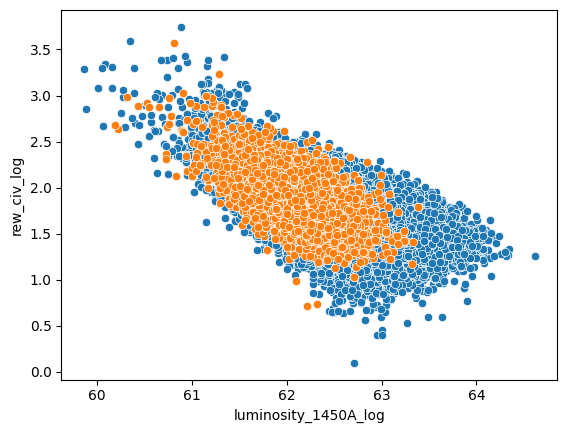

In [11]:
sns.scatterplot(data=results_copy,x="luminosity_1450A_log",y="rew_civ_log")
sns.scatterplot(data=results_copy[(results_copy["z-w3"]>3.9) & (results_copy["z"]>2) & (results_copy["z"]<3.4) & (results_copy["snr_w3"]>3)],x="luminosity_1450A_log",y="rew_civ_log")
# plt.xscale("log")
# plt.yscale("log")

<Axes: xlabel='luminosity_1450A_log', ylabel='rew_civ_log'>

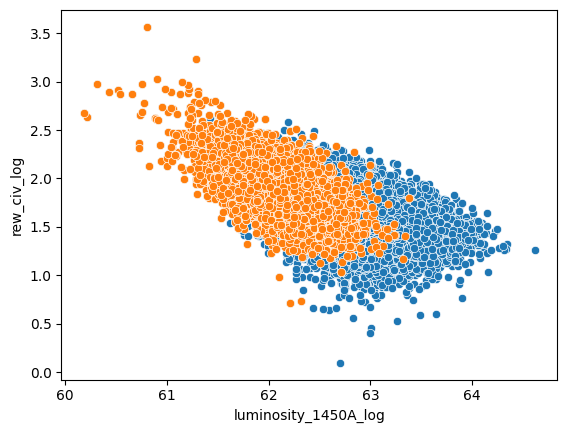

In [12]:
sns.scatterplot(data=results_copy[(results_copy["snr_w3"]>3)],x="luminosity_1450A_log",y="rew_civ_log")
sns.scatterplot(data=results_copy[(results_copy["z-w3"]>3.9) & (results_copy["z"]>2) & (results_copy["z"]<3.4) & (results_copy["snr_w3"]>3)],x="luminosity_1450A_log",y="rew_civ_log")
# plt.xscale("log")
# plt.yscale("log")

In [13]:
# # Source - https://stackoverflow.com/a/25015798
# # Posted by Amelio Vazquez-Reina
# # Retrieved 2026-09-15, License - CC BY-SA 3.0

# with pd.option_context('mode.use_inf_as_null', True):
#    df = results_copy[["rew_civ_log"]].dropna()


In [21]:
plot_df = results_copy[(results_copy["rew_civ_log"].notna()) & np.isfinite(results_copy["rew_civ_log"]) & (results_copy["luminosity_1450A_log"].notna()) & np.isfinite(results_copy["luminosity_1450A_log"]) & (results_copy["z"]>2) & (results_copy["z"]<3.4)]

# contour_scatter_plot(plot_df.head(100),x="luminosity_1450A_log",y="rew_civ_log",subsample_col=None,y_threshold=None)

[]

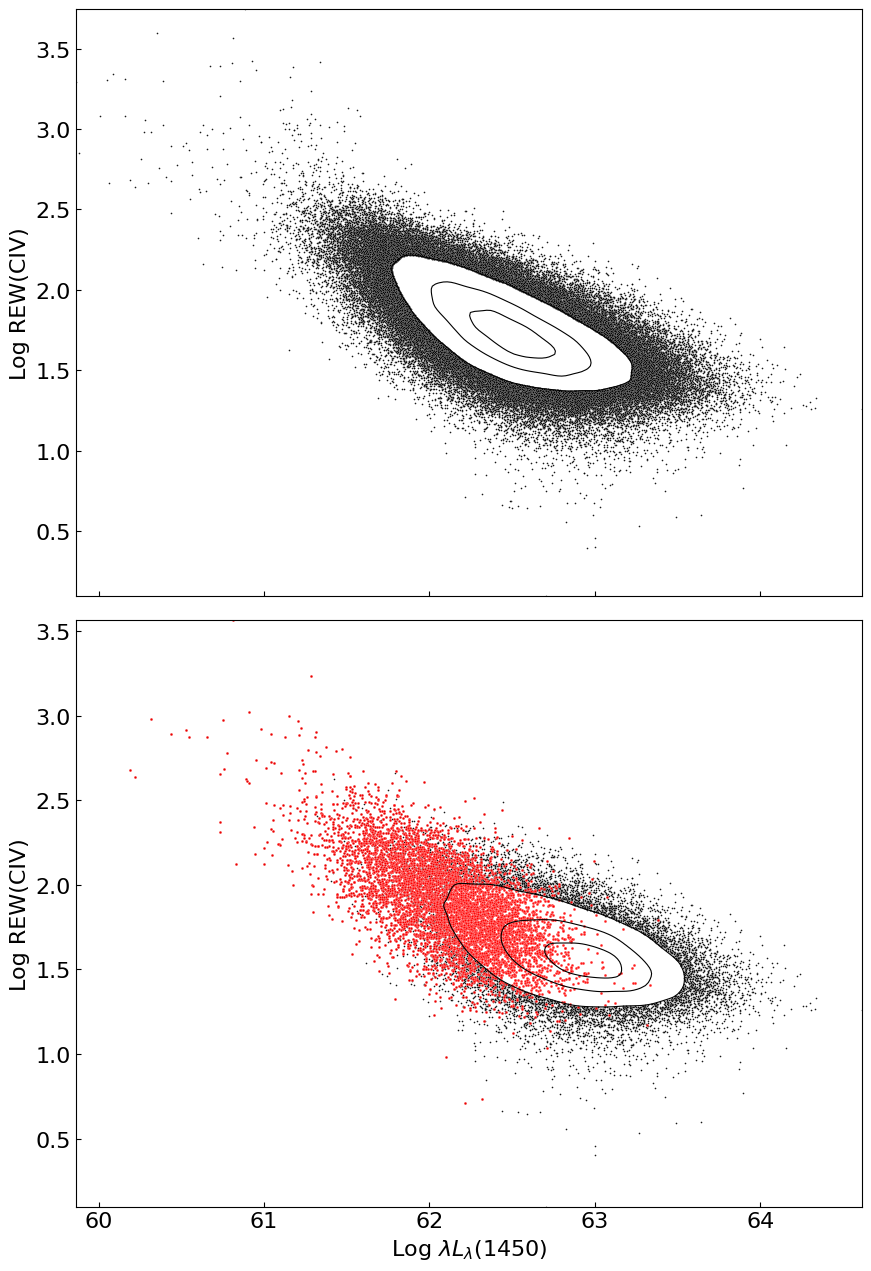

In [32]:
fig, axes = plt.subplots(2,1,figsize=(9,13),sharex=True)

contour_scatter_plot(plot_df,x="luminosity_1450A_log",y="rew_civ_log",subsample_col=None,y_threshold=None,ax=axes[0],x_label=r"Log $\lambda L_{\lambda}(1450)$",y_label="Log REW(CIV)")

contour_scatter_plot(plot_df[(plot_df["flux_w3"].notna()) & (plot_df["snr_w3"]>3)],x="luminosity_1450A_log",y="rew_civ_log",subsample_col="z-w3",subsample_cutoff=3.9,y_threshold=None,ax=axes[1],x_label=r"Log $\lambda L_{\lambda}(1450)$",y_label="Log REW(CIV)")

plt.tight_layout()

plt.savefig("images/baldwin-plot.png")

plt.plot()

In [22]:
print(r"Log $\lambdaL_{\lambda}")

Log $\lambdaL_{\lambda}


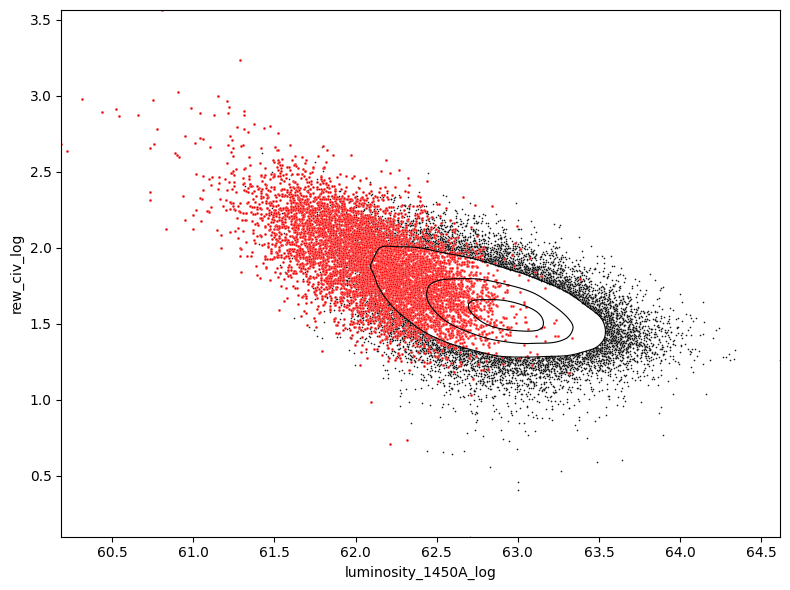

In [20]:
contour_scatter_plot(plot_df[(plot_df["flux_w3"].notna()) & (plot_df["snr_w3"]>3)],x="luminosity_1450A_log",y="rew_civ_log",subsample_col="z-w3",subsample_cutoff=3.9,y_threshold=None)

In [ ]:
# cont_params = ast.literal_eval(fit_params.loc[targetid,"continuum_fit_lya_nv"])["fit_params"]

# flux_1450A = _powerlaw(1450/1290,**cont_params)
# flux_1450A

0.5066954665668522

In [ ]:
# z = results.loc[targetid,"z"]
# z

2.644168212056648

In [ ]:
# D_L_cm = cosmo.luminosity_distance(z).to(u.cm).value
# L_1450A = (D_L_cm**2)*4*np.pi*flux_1450A*1450

In [ ]:
# L_1450A

4.320516911486529e+61

#### CIV blueshift

In [36]:
for idx in fit_params.index:
    civ_params = ast.literal_eval(fit_params.loc[idx,"line_fit_civ"])["fit_params"]
    lya_params = ast.literal_eval(fit_params.loc[idx,"line_fit_lya"])["fit_params"]

    civ_peak = civ_params["center"] if len(civ_params)==3 else civ_params["cen_c"]
    lya_peak = lya_params["center"] if len(lya_params)==3 else lya_params["cen_c"]

    fit_params.loc[idx,"civ_shift_vel"] = lam_to_vel(civ_peak,lam0=CIV_AIR)
    fit_params.loc[idx,"lya_shift_vel"] = lam_to_vel(lya_peak,lam0=LYA_AIR)

In [38]:
fit_params["shift_diff"] = fit_params["civ_shift_vel"] - fit_params["lya_shift_vel"]

fit_params[["civ_shift_vel","lya_shift_vel","shift_diff"]].describe()

,civ_shift_vel,lya_shift_vel,shift_diff
count,186890.000000,186890.000000,186890.000000
mean,-291.482036,98.893230,-390.375266
std,535.096297,738.296601,704.591129
min,-8611.633917,-49290.319107,-24007.302789
25%,-524.146448,-40.361276,-670.319222
50%,-205.394484,224.890145,-360.229492
75%,32.451408,419.939717,-113.771675
max,9004.336028,22932.319286,48550.643378


In [48]:
erq_idxs = results[(results["z-w3"]>3.9) & (results["z"]>2) & (results["z"]<3.4) & (results["snr_w3"]>3)].index

fit_params[fit_params.index.isin(erq_idxs)][["civ_shift_vel","lya_shift_vel","shift_diff"]].describe()

,civ_shift_vel,lya_shift_vel,shift_diff
count,6376.000000,6376.000000,6376.000000
mean,-168.525434,129.397553,-297.922987
std,488.128960,849.889934,916.954251
min,-6485.385268,-28765.022959,-12923.288652
25%,-351.051357,17.233024,-543.643458
50%,-83.999855,199.607336,-245.493878
75%,103.052839,361.665121,-25.991512
max,1696.392306,11132.742743,28895.605742
